1: Import thư viện

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Thư viện cho encoding
from sklearn.model_selection import KFold
from category_encoders import CatBoostEncoder

print("Thư viện đã sẵn sàng.")

Thư viện đã sẵn sàng.


2: Đọc dữ liệu gốc và tiền xử lý dữ liệu

In [122]:
df = pd.read_csv('retail_sales_dataset.csv')
print(f"Kích thước dữ liệu gốc: {df.shape}")
df.head()

Kích thước dữ liệu gốc: (120000, 17)


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


Kiểm tra dòng trùng lặp

In [123]:
# Kiểm tra số lượng bản ghi trùng lặp
df.duplicated().sum()

np.int64(0)

Kiểm tra danh sách cột

In [124]:
# Kiểm tra các cột trong DataFrame
df.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

Kiểm tra kiểu dữ liệu

In [125]:
# Kiểm tra kiểu dữ liệu của các cột
df.dtypes

transaction_id            str
transaction_date          str
customer_id               str
customer_gender           str
customer_age_group        str
customer_segment          str
product_id                str
product_name              str
category                  str
brand                     str
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method            str
sales_channel             str
region                    str
dtype: object

Thống kê mô tả các cột số

In [126]:
df.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


Tỉ lệ phân bố các cột

In [144]:
# Kiểm tra phân bố các cột phân loại
categorical_cols = ['customer_gender', 'customer_age_group', 'customer_segment', 
                    'category', 'brand', 'payment_method', 'sales_channel', 'region']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


customer_gender:
customer_gender
Female    33.6%
Other     33.3%
Male      33.2%
Name: proportion, dtype: str

customer_age_group:
customer_age_group
35-44    20.2%
55+      20.1%
18-24    20.0%
45-54    19.9%
25-34    19.9%
Name: proportion, dtype: str

customer_segment:
customer_segment
VIP          25.1%
New          25.0%
Loyal        25.0%
Returning    24.9%
Name: proportion, dtype: str

category:
category
Sports         12.7%
Clothing       12.6%
Beauty         12.6%
Groceries      12.5%
Toys           12.5%
Electronics    12.5%
Home           12.4%
Books          12.1%
Name: proportion, dtype: str

brand:
brand
Brand 1    33.5%
Brand 2    33.3%
Brand 3    33.2%
Name: proportion, dtype: str

payment_method:
payment_method
Credit Card    20.2%
Cash           20.0%
PayPal         20.0%
Debit Card     19.9%
Gift Card      19.8%
Name: proportion, dtype: str

sales_channel:
sales_channel
Mobile App    33.5%
In-Store      33.4%
Online        33.1%
Name: proportion, dtype: str

region:

Drop các cột không cần thiết 

In [127]:
df.drop(columns=['transaction_id', 'customer_id', 'product_name'], inplace=True, errors='ignore')
df.shape

(120000, 14)

3: Data Cleaning –  Xử lý outlier, xử lý missing và chuẩn hóa kiểu

Loại bỏ dữ liệu bất thường và kiểm tra missing value

In [128]:
# Loại bỏ dữ liệu bất thường
initial_len = len(df)
df = df[df['quantity'] > 0]
df = df[df['unit_price'] > 0]
df = df[df['sales_amount'] >= 0]   
# Kiểm tra các giá trị thiếu trong DataFrame sau khi loại bỏ các cột không cần thiết
df.isnull().sum()

transaction_date      0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

Boxplot cho sale_amount

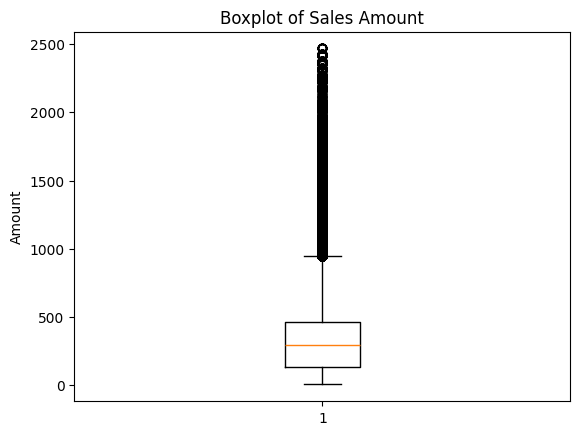

In [129]:
# Vẽ biểu đồ boxplot để kiểm tra phân phối của cột 'sales_amount'
plt.boxplot(df['sales_amount'])
plt.title("Boxplot of Sales Amount")
plt.ylabel("Amount")
plt.show()

Lọc outlier của sales_amount bằng IQR

In [130]:
# Dùng phương pháp IQR để xác định ngưỡng cho outliers
Q1 = df['sales_amount'].quantile(0.25)
Q3 = df['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df[(df.sales_amount < lower_limit) | (df.sales_amount > upper_limit)]

,transaction_date,customer_gender,customer_age_group,customer_segment,product_id,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
10,2024-02-27,Male,35-44,VIP,P1108,Books,Brand 3,4,379.00,0,1516.00,Cash,Online,South
21,2025-06-24,Female,25-34,Returning,P1034,Groceries,Brand 1,2,474.70,0,949.40,Cash,In-Store,East
29,2025-04-18,Male,45-54,New,P1036,Groceries,Brand 3,4,405.16,0,1620.64,Credit Card,Mobile App,Central
36,2025-08-31,Other,18-24,VIP,P1075,Home,Brand 3,3,354.89,5,1011.44,Gift Card,Mobile App,Central
46,2024-02-06,Other,55+,Returning,P1070,Home,Brand 1,2,493.51,0,987.02,PayPal,Online,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119967,2025-01-15,Male,25-34,New,P1010,Electronics,Brand 1,4,355.50,0,1422.00,Credit Card,Online,South
119978,2025-11-29,Female,18-24,Loyal,P1003,Electronics,Brand 3,4,367.34,0,1469.36,Credit Card,Online,East
119981,2024-02-29,Female,25-34,Loyal,P1074,Home,Brand 2,4,408.65,5,1552.87,Credit Card,Online,North
119983,2025-06-04,Other,55+,Returning,P1077,Sports,Brand 2,3,386.78,0,1160.34,PayPal,Mobile App,West


Chuẩn hóa dữ liệu

In [131]:
# Chuyển cột ngày sang datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Chuyển các cột số sang kiểu số (lỗi -> NaN)
for col in ['quantity', 'unit_price', 'discount_pct', 'sales_amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

4: Data Aggregation

In [133]:
agg_df = df.groupby(
    ['transaction_date', 'product_id', 'customer_segment', 'customer_gender'],
    as_index=False
).agg(
    sales_amount_sum=('sales_amount', 'sum'),
    quantity_sum=('quantity', 'sum'),
    avg_discount=('discount_pct', 'mean'),
    transaction_count=('sales_amount', 'count')   # thay transaction_id bằng sales_amount
)

# Bổ sung các cột thuộc tính cố định (category, brand, region, customer_age_group, sales_channel, payment_method)
meta_cols = ['category', 'brand', 'region', 'customer_age_group', 'sales_channel', 'payment_method']
for col in meta_cols:
    mode_series = df.groupby(['product_id', 'customer_segment', 'customer_gender'])[col].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    )
    agg_df = agg_df.merge(mode_series.reset_index(name=col), 
                          on=['product_id', 'customer_segment', 'customer_gender'], 
                          how='left')

print(f"Kích thước sau aggregation: {agg_df.shape}")
print("Số dòng theo nhóm (product, segment, gender, date):", agg_df.shape[0])
agg_df.head()
# Xóa các cột định danh (nếu có)
for col in ['transaction_id', 'customer_id', 'product_name']:
    if col in agg_df.columns:
        agg_df.drop(columns=[col], inplace=True)

Kích thước sau aggregation: (113283, 14)
Số dòng theo nhóm (product, segment, gender, date): 113283


5: Feature Engineering – Time Features

In [134]:
agg_df['year'] = agg_df['transaction_date'].dt.year
agg_df['month'] = agg_df['transaction_date'].dt.month
agg_df['quarter'] = agg_df['transaction_date'].dt.quarter
agg_df['day_of_week'] = agg_df['transaction_date'].dt.dayofweek   # 0=Monday
agg_df['week_of_year'] = agg_df['transaction_date'].dt.isocalendar().week
agg_df['is_weekend'] = (agg_df['day_of_week'] >= 5).astype(int)

agg_df[['transaction_date', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend']].head()

,transaction_date,year,month,quarter,day_of_week,is_weekend
0,2024-01-01,2024,1,1,0,0
1,2024-01-01,2024,1,1,0,0
2,2024-01-01,2024,1,1,0,0
3,2024-01-01,2024,1,1,0,0
4,2024-01-01,2024,1,1,0,0


6: Discount Features

In [135]:
agg_df['is_promoted'] = (agg_df['avg_discount'] > 0).astype(int)

def discount_level(disc):
    if disc == 0:
        return 'No Sale'
    elif disc <= 10:
        return 'Low Sale'
    elif disc <= 20:
        return 'Medium Sale'
    else:
        return 'High Sale'

agg_df['discount_level'] = agg_df['avg_discount'].apply(discount_level)

# Xem phân phối mức giảm giá
agg_df['discount_level'].value_counts()

discount_level
No Sale        66391
Low Sale       24453
Medium Sale    15984
High Sale       6455
Name: count, dtype: int64

7: Interaction Features

In [136]:
# Discount × Customer Segment
segment_weight = {'VIP':3, 'Loyal':2, 'Returning':1, 'New':0, 'Unknown':0}
agg_df['discount_segment_interaction'] = agg_df['avg_discount'] * agg_df['customer_segment'].map(segment_weight)

# Discount × Gender
gender_weight = {'Female':1, 'Male':2, 'Other':0, 'Unknown':0}
agg_df['discount_gender_interaction'] = agg_df['avg_discount'] * agg_df['customer_gender'].map(gender_weight)

agg_df[['avg_discount', 'customer_segment', 'customer_gender', 
        'discount_segment_interaction', 'discount_gender_interaction']].head()

,avg_discount,customer_segment,customer_gender,discount_segment_interaction,discount_gender_interaction
0,20.0,Loyal,Male,40.0,40.0
1,25.0,New,Other,0.0,0.0
2,0.0,Returning,Male,0.0,0.0
3,0.0,VIP,Other,0.0,0.0
4,0.0,Loyal,Female,0.0,0.0


8 : Historical Features 

In [137]:
# Sắp xếp theo nhóm và thời gian
agg_df = agg_df.sort_values(['product_id', 'customer_segment', 'customer_gender', 'transaction_date'])

# === Lag features (giữ nguyên, đã đúng) ===
agg_df['sales_lag_1'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['sales_amount_sum'].shift(1)
agg_df['sales_lag_7'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['sales_amount_sum'].shift(7)
agg_df['sales_lag_30'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['sales_amount_sum'].shift(30)

# === Rolling mean KHÔNG BAO GỒM HIỆN TẠI ===
# Cách: shift 1 trước khi rolling
def rolling_mean_excluding_current(series, window):
    shifted = series.shift(1)
    return shifted.rolling(window, min_periods=1).mean()

# Áp dụng cho sales
agg_df['sales_roll_mean_7'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['sales_amount_sum'] \
                                .transform(lambda x: rolling_mean_excluding_current(x, 7))
agg_df['sales_roll_mean_30'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['sales_amount_sum'] \
                                 .transform(lambda x: rolling_mean_excluding_current(x, 30))

# Rolling quantity
agg_df['qty_roll_mean_30'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['quantity_sum'] \
                              .transform(lambda x: rolling_mean_excluding_current(x, 30))

# Rolling discount
agg_df['discount_roll_mean_30'] = agg_df.groupby(['product_id', 'customer_segment', 'customer_gender'])['avg_discount'] \
                                   .transform(lambda x: rolling_mean_excluding_current(x, 30))

# Điền NA (những ngày đầu) bằng 0
roll_cols = ['sales_roll_mean_7', 'sales_roll_mean_30', 'qty_roll_mean_30', 'discount_roll_mean_30']
agg_df[roll_cols] = agg_df[roll_cols].fillna(0)

agg_df[['transaction_date', 'sales_amount_sum', 'sales_roll_mean_7', 'sales_roll_mean_30']].head()

,transaction_date,sales_amount_sum,sales_roll_mean_7,sales_roll_mean_30
949,2024-01-07,180.88,0.000000,0.000000
2208,2024-01-15,380.80,180.880000,180.880000
4195,2024-01-28,190.40,280.840000,280.840000
6399,2024-02-11,180.88,250.693333,250.693333
10412,2024-03-08,190.40,233.240000,233.240000


9: Chia tập train/test theo thời gian (80-20)

In [138]:
# Sắp xếp theo thời gian trước khi chia
agg_df_sorted = agg_df.sort_values('transaction_date').reset_index(drop=True)

n = len(agg_df_sorted)
train_size = int(n * 0.8)

train = agg_df_sorted.iloc[:train_size].copy()
test = agg_df_sorted.iloc[train_size:].copy()

print(f"Train: {len(train)} dòng (80%)")
print(f"Test: {len(test)} dòng (20%)")

Train: 90626 dòng (80%)
Test: 22657 dòng (20%)


10: One-Hot Encoding cho các cột phân loại có ít giá trị (chỉ train/test)

In [139]:
ohe_cols = ['customer_gender', 'sales_channel', 'payment_method', 'discount_level']

train = pd.get_dummies(train, columns=ohe_cols, prefix=ohe_cols, dtype=int)
test = pd.get_dummies(test, columns=ohe_cols, prefix=ohe_cols, dtype=int)

# Đồng bộ cột giữa train và test (đảm bảo test có đủ các cột như train)
for col in train.columns:
    if col not in test.columns:
        test[col] = 0
for col in test.columns:
    if col not in train.columns:
        train[col] = 0

# Sắp xếp cột nhất quán (không bắt buộc nhưng tiện)
train = train[train.columns.sort_values()]
test = test[test.columns.sort_values()]

print("Số cột sau one-hot (train):", train.shape[1])
print("Số cột sau one-hot (test):", test.shape[1])

Số cột sau one-hot (train): 42
Số cột sau one-hot (test): 42


11: Target Encoding using CatBoostEncoder (chỉ train/test)

In [140]:
from category_encoders import CatBoostEncoder

cat_features = ['product_id', 'category', 'brand', 'customer_segment', 'region']
target = 'sales_amount_sum'

encoder = CatBoostEncoder(cols=cat_features, verbose=0)

# Fit trên train
encoder.fit(train[cat_features], train[target])

# Transform train và test
train_encoded = encoder.transform(train[cat_features])
test_encoded = encoder.transform(test[cat_features])

# Gán cột đã encode
for col in cat_features:
    train[col + '_te'] = train_encoded[col]
    test[col + '_te'] = test_encoded[col]

# Xóa cột gốc
train.drop(columns=cat_features, inplace=True)
test.drop(columns=cat_features, inplace=True)

print("Sau target encoding, số cột train:", train.shape[1])
print("Sau target encoding, số cột test:", test.shape[1])

Sau target encoding, số cột train: 42
Sau target encoding, số cột test: 42


12: Xóa các cột không dùng cho mô hình

In [141]:
drop_cols = ['transaction_date']   # chỉ xóa ngày tháng (đã dùng để tạo time features)
for col in drop_cols:
    if col in train.columns:
        train.drop(columns=[col], inplace=True)
    if col in test.columns:
        test.drop(columns=[col], inplace=True)
print("Các cột cuối cùng trong train:", train.columns.tolist())
drop_cols_extra = ['quantity_sum', 'transaction_count']
train.drop(columns=drop_cols_extra, inplace=True, errors='ignore')
test.drop(columns=drop_cols_extra, inplace=True, errors='ignore')

Các cột cuối cùng trong train: ['avg_discount', 'customer_age_group', 'customer_gender_Female', 'customer_gender_Male', 'customer_gender_Other', 'day_of_week', 'discount_gender_interaction', 'discount_level_High Sale', 'discount_level_Low Sale', 'discount_level_Medium Sale', 'discount_level_No Sale', 'discount_roll_mean_30', 'discount_segment_interaction', 'is_promoted', 'is_weekend', 'month', 'payment_method_Cash', 'payment_method_Credit Card', 'payment_method_Debit Card', 'payment_method_Gift Card', 'payment_method_PayPal', 'qty_roll_mean_30', 'quantity_sum', 'quarter', 'sales_amount_sum', 'sales_channel_In-Store', 'sales_channel_Mobile App', 'sales_channel_Online', 'sales_lag_1', 'sales_lag_30', 'sales_lag_7', 'sales_roll_mean_30', 'sales_roll_mean_7', 'transaction_count', 'week_of_year', 'year', 'product_id_te', 'category_te', 'brand_te', 'customer_segment_te', 'region_te']


13: Lưu kết quả ra file CSV 

In [142]:
train.to_csv('train_preprocessed.csv', index=False)
test.to_csv('test_preprocessed.csv', index=False)
print("Đã lưu các tập tin: train_preprocessed.csv, val_preprocessed.csv, test_preprocessed.csv")

Đã lưu các tập tin: train_preprocessed.csv, val_preprocessed.csv, test_preprocessed.csv
